# Thử nghiệm Quy trình Trích xuất Đa phương thức (Multimodal Data Ingestion)
**Mục tiêu:** Notebook này nhằm mục đích thử nghiệm và trực quan hóa bước đầu tiên trong pipeline Multimodal RAG:
1. Tách âm thanh từ file video bài giảng (`.mp4`).
2. Sử dụng mô hình ASR **PhoWhisper** để bóc băng (transcript) giọng nói tiếng Việt kèm mốc thời gian (timestamps).
3. Trích xuất các khung hình chính (keyframes) từ video.
4. Sử dụng **PaddleOCR** để nhận diện và trích xuất văn bản từ ảnh slide.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q faster-whisper moviepy opencv-python matplotlib
!pip install -q transformers accelerate torch torchvision
!pip install -q timm pillow
# Cài đặt DeepSeek-VL từ source (vì thường không có trên PyPI chuẩn)
!pip install -q git+https://github.com/deepseek-ai/DeepSeek-VL.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.0/39.0 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 105.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
import os
import cv2
import torch
import json
import subprocess
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from faster_whisper import WhisperModel
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from deepseek_vl.models import MultiModalityCausalLM, VLChatProcessor
from deepseek_vl.utils.io import load_pil_images
from skimage.metrics import structural_similarity as ssim

Python version is above 3.10, patching the collections module.


In [4]:
INPUT_FOLDER = "/content/drive/MyDrive/video/cs431_data"
BASE_OUTPUT_DIR = "/content/drive/MyDrive/video/outputs_processed"
# Định nghĩa 3 thư mục gốc
# 3 thư mục gốc chính
AUDIO_BASE = os.path.join(BASE_OUTPUT_DIR, "audio")
TRANSCRIPT_BASE = os.path.join(BASE_OUTPUT_DIR, "transcripts")
FRAME_BASE = os.path.join(BASE_OUTPUT_DIR, "keyframes")

for d in [AUDIO_BASE, TRANSCRIPT_BASE, FRAME_BASE]:
    os.makedirs(d, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("--- Đang tải các mô hình tốt nhất (Whisper Large-v3 & Qwen2-VL)... ---")

# ASR Model
whisper_model = WhisperModel("large-v3", device=device, compute_type="float16" if device=="cuda" else "int8")

# OCR Model
qwen_id = "Qwen/Qwen2-VL-2B-Instruct"
qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(qwen_id, torch_dtype="auto", device_map="auto")
qwen_processor = AutoProcessor.from_pretrained(qwen_id)

print("--- Hệ thống sẵn sàng ---")

--- Đang tải các mô hình tốt nhất (Whisper Large-v3 & Qwen2-VL)... ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

--- Hệ thống sẵn sàng ---


## Trích xuất âm thanh (Audio Extraction)

In [5]:
# def extract_audio(video_path, audio_path):
#     print(f"   > Đang tách audio: {os.path.basename(audio_path)}")
#     command = ["ffmpeg", "-y", "-i", video_path, "-vn", "-acodec", "pcm_s16le", "-ar", "16000", "-ac", "1", audio_path]
#     subprocess.run(command, capture_output=True, text=True)

# # Chạy tách audio cho toàn bộ danh sách
# video_files = [f for f in os.listdir(INPUT_FOLDER) if f.lower().endswith(('.mp4', '.avi', '.mkv'))]
# for video_file in video_files:
#     v_name = os.path.splitext(video_file)[0]
#     audio_file_path = os.path.join(AUDIO_BASE, f"{v_name}.wav")

#     if not os.path.exists(audio_file_path):
#         extract_audio(os.path.join(INPUT_FOLDER, video_file), audio_file_path)
#     else:
#         print(f"--- Đã có audio cho '{v_name}', bỏ qua ---")

# print("\n--- HOÀN TẤT TÁCH AUDIO ---")

   > Đang tách audio: [CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.1 Giới thiệu môn học.wav
   > Đang tách audio: [CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.2 Lịch sử AI và thành tựu của Deep learning.wav
   > Đang tách audio: [CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.1 Ôn tập nền tảng đại số tuyến tính (Part 1).wav
   > Đang tách audio: [CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.2 Ôn tập nền tảng đại số tuyến tính (Part 2).wav
   > Đang tách audio: [CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.3 Ôn tập nền tảng đại số tuyến tính (Part 3).wav
   > Đang tách audio: [CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.4 Ôn tập nền tảng đại số tuyến tính (Part 4).wav
   > Đang tách audio: [CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.4.1 Ôn tập nền tảng giải tích (Part 1).wav
   > Đang tách audio: [CS431 

In [6]:
# import os, json, torch
# from faster_whisper import WhisperModel

# # Cấu hình
# TRANSCRIPT_BASE = os.path.join(BASE_OUTPUT_DIR, "transcripts")
# os.makedirs(TRANSCRIPT_BASE, exist_ok=True)
# device = "cuda" if torch.cuda.is_available() else "cpu"

# print("--- Đang tải Whisper Large-v3... ---")
# whisper_model = WhisperModel("large-v3", device=device, compute_type="float16" if device=="cuda" else "int8")

# video_files = [f for f in os.listdir(INPUT_FOLDER) if f.lower().endswith(('.mp4', '.avi', '.mkv'))]
# for video_file in video_files:
#     v_name = os.path.splitext(video_file)[0]
#     audio_path = os.path.join(AUDIO_BASE, f"{v_name}.wav")
#     asr_json_path = os.path.join(TRANSCRIPT_BASE, f"{v_name}_asr.json")

#     if os.path.exists(asr_json_path):
#         print(f"--- Đã có transcript cho '{v_name}', bỏ qua ---")
#         continue

#     print(f">>>> ĐANG ASR: {v_name}")
#     segments, _ = whisper_model.transcribe(audio_path, language="vi", beam_size=5, vad_filter=True)
#     transcript_result = [{"start": round(s.start, 2), "end": round(s.end, 2), "text": s.text.strip()} for s in segments]

#     with open(asr_json_path, "w", encoding="utf-8") as f:
#         json.dump(transcript_result, f, ensure_ascii=False, indent=4)

# # Giải phóng bộ nhớ
# del whisper_model
# if torch.cuda.is_available(): torch.cuda.empty_cache()
# print("\n--- HOÀN TẤT BÓC BĂNG ---")

--- Đang tải Whisper Large-v3... ---
>>>> ĐANG ASR: [CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.1 Giới thiệu môn học
>>>> ĐANG ASR: [CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.2 Lịch sử AI và thành tựu của Deep learning
>>>> ĐANG ASR: [CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.1 Ôn tập nền tảng đại số tuyến tính (Part 1)
>>>> ĐANG ASR: [CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.2 Ôn tập nền tảng đại số tuyến tính (Part 2)
>>>> ĐANG ASR: [CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.3 Ôn tập nền tảng đại số tuyến tính (Part 3)
>>>> ĐANG ASR: [CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.4 Ôn tập nền tảng đại số tuyến tính (Part 4)
>>>> ĐANG ASR: [CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.4.1 Ôn tập nền tảng giải tích (Part 1)
>>>> ĐANG ASR: [CS431 - Các kĩ thuật học sâu và ứng dụng] V

In [7]:
# import cv2, os
# from skimage.metrics import structural_similarity as ssim

# FRAME_BASE = os.path.join(BASE_OUTPUT_DIR, "keyframes")
# os.makedirs(FRAME_BASE, exist_ok=True)

# def is_new_slide(imgA, imgB, threshold=0.96):
#     if imgB is None: return True
#     grayA = cv2.cvtColor(imgA, cv2.COLOR_BGR2GRAY)
#     grayB = cv2.cvtColor(imgB, cv2.COLOR_BGR2GRAY)
#     if grayA.shape != grayB.shape: grayB = cv2.resize(grayB, (grayA.shape[1], grayA.shape[0]))
#     score, _ = ssim(grayA, grayB, full=True)
#     return score < threshold

# video_files = [f for f in os.listdir(INPUT_FOLDER) if f.lower().endswith(('.mp4', '.avi', '.mkv'))]
# for video_file in video_files:
#     v_name = os.path.splitext(video_file)[0]
#     v_path = os.path.join(INPUT_FOLDER, video_file)
#     v_frame_dir = os.path.join(FRAME_BASE, v_name)
#     os.makedirs(v_frame_dir, exist_ok=True)

#     print(f">>>> ĐANG TRÍCH XUẤT FRAME: {v_name}")
#     cap = cv2.VideoCapture(v_path)
#     fps = cap.get(cv2.CAP_PROP_FPS)
#     duration = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) / fps)

#     prev_frame = None
#     for ts in range(0, duration, 20):
#         frame_id = int(fps * ts)
#         cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
#         ret, frame = cap.read()
#         if not ret: break

#         if is_new_slide(frame, prev_frame):
#             cv2.imwrite(os.path.join(v_frame_dir, f"{v_name}_frame_{ts}s.jpg"), frame)
#             prev_frame = frame.copy()
#     cap.release()

# print("\n--- HOÀN TẤT TRÍCH XUẤT KEYFRAMES ---")

>>>> ĐANG TRÍCH XUẤT FRAME: [CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.1 Giới thiệu môn học
>>>> ĐANG TRÍCH XUẤT FRAME: [CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.2 Lịch sử AI và thành tựu của Deep learning
>>>> ĐANG TRÍCH XUẤT FRAME: [CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.1 Ôn tập nền tảng đại số tuyến tính (Part 1)
>>>> ĐANG TRÍCH XUẤT FRAME: [CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.2 Ôn tập nền tảng đại số tuyến tính (Part 2)
>>>> ĐANG TRÍCH XUẤT FRAME: [CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.3 Ôn tập nền tảng đại số tuyến tính (Part 3)
>>>> ĐANG TRÍCH XUẤT FRAME: [CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.4 Ôn tập nền tảng đại số tuyến tính (Part 4)
>>>> ĐANG TRÍCH XUẤT FRAME: [CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.4.1 Ôn tập nền tảng giải tích (Part 1)
>>>> ĐANG TRÍCH

In [10]:
import os, json, torch
from PIL import Image
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

print("--- Đang tải Qwen2-VL-2B... ---")
qwen_id = "Qwen/Qwen2-VL-2B-Instruct"
qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(qwen_id, torch_dtype="auto", device_map="auto")
qwen_processor = AutoProcessor.from_pretrained(qwen_id)

video_files = [f for f in os.listdir(INPUT_FOLDER) if f.lower().endswith(('.mp4', '.avi', '.mkv'))]
for video_file in video_files:
    v_name = os.path.splitext(video_file)[0]
    v_frame_dir = os.path.join(FRAME_BASE, v_name)
    ocr_json_path = os.path.join(TRANSCRIPT_BASE, f"{v_name}_ocr.json")

    if os.path.exists(ocr_json_path):
        print(f"--- Đã có OCR cho '{v_name}', bỏ qua ---")
        continue

    print(f">>>> ĐANG CHẠY OCR: {v_name}")
    ocr_results = []
    frame_files = sorted([f for f in os.listdir(v_frame_dir) if f.endswith('.jpg')])

    for f_name in frame_files:
        f_path = os.path.join(v_frame_dir, f_name)
        image = Image.open(f_path)
        messages = [{"role": "user", "content": [{"type": "image", "image": f_path}, {"type": "text", "text": "Trích xuất văn bản tiếng Việt."}]}]
        text = qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = qwen_processor(text=[text], images=[image], padding=True, return_tensors="pt").to("cuda")

        with torch.no_grad():
            ids = qwen_model.generate(**inputs, max_new_tokens=512)
            res = qwen_processor.batch_decode(ids[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0]

        ts = f_name.split('_')[-1].replace('s.jpg', '')
        ocr_results.append({"ts": int(ts), "image": f_name, "text": res})

    with open(ocr_json_path, "w", encoding="utf-8") as f:
        json.dump(ocr_results, f, ensure_ascii=False, indent=4)

print("\n--- HOÀN TẤT TOÀN BỘ QUY TRÌNH ---")

--- Đang tải Qwen2-VL-2B... ---


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

--- Đã có OCR cho '[CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.1 Giới thiệu môn học', bỏ qua ---
--- Đã có OCR cho '[CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.2 Lịch sử AI và thành tựu của Deep learning', bỏ qua ---
--- Đã có OCR cho '[CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.1 Ôn tập nền tảng đại số tuyến tính (Part 1)', bỏ qua ---
--- Đã có OCR cho '[CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.2 Ôn tập nền tảng đại số tuyến tính (Part 2)', bỏ qua ---
--- Đã có OCR cho '[CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.3 Ôn tập nền tảng đại số tuyến tính (Part 3)', bỏ qua ---
--- Đã có OCR cho '[CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.4 Ôn tập nền tảng đại số tuyến tính (Part 4)', bỏ qua ---
--- Đã có OCR cho '[CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.4.1 Ôn tập nền tảng giải tích (Part 1)'

OutOfMemoryError: CUDA out of memory. Tried to allocate 1.37 GiB. GPU 0 has a total capacity of 14.56 GiB of which 153.81 MiB is free. Including non-PyTorch memory, this process has 14.41 GiB memory in use. Of the allocated memory 14.11 GiB is allocated by PyTorch, and 172.33 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [31]:
# # Chạy thử nghiệm
# if os.path.exists(VIDEO_PATH):
#     extract_audio(VIDEO_PATH, AUDIO_PATH)

--- Đang trích xuất âm thanh từ: /content/drive/MyDrive/video/videoplayback.mp4 ---
Đã lưu file audio tại: /content/drive/MyDrive/video/testdata/extracted_audio.wav


### Trích xuất transcripts

In [32]:
# def transcribe_audio(audio_path):
#     print("--- Đang tải mô hình Faster Whisper (Large-v3)... ---")

#     # Sử dụng "large-v3" để có chất lượng tiếng Việt tốt nhất hiện nay
#     model = WhisperModel(
#         "large-v3",
#         device=device,
#         compute_type="float16" if device == "cuda" else "int8"
#     )

#     print("--- Đang thực hiện transcribe audio... ---")
#     segments, info = model.transcribe(
#         audio_path,
#         language="vi",
#         beam_size=5,
#         vad_filter=True,
#         condition_on_previous_text=False,
#         temperature=0
#     )

#     transcript = []
#     print("\nKết quả transcript (5 đoạn đầu):")
#     for i, segment in enumerate(segments):
#         text = segment.text.strip()
#         transcript.append(text)
#         if i < 5:
#             print(f"[{segment.start:.2f}s -> {segment.end:.2f}s] {text}")

#     return " ".join(transcript)

In [33]:
# # Thực thi bóc băng
# if os.path.exists(AUDIO_PATH):
#     full_text = transcribe_audio(AUDIO_PATH)

--- Đang tải mô hình Faster Whisper (Large-v3)... ---
--- Đang thực hiện transcribe audio... ---

Kết quả transcript (5 đoạn đầu):
[15.06s -> 18.86s] Chào các bạn, hôm nay chúng ta sẽ đến với bài về xử lý ngôn ngữ tự nhiên
[18.86s -> 23.56s] Trong các bài trước thì chúng ta đã làm việc trên loại dữ liệu đó là dữ liệu ảnh
[23.56s -> 26.92s] Còn từ nay cho về sau thì chúng ta sẽ đến với một loại dữ liệu đặc biệt
[26.92s -> 28.32s] Đó chính là loại dữ liệu văn bản
[28.32s -> 33.20s] Và làm sao để có thể biểu diễn được các từ trong văn bản


### Trích xuất Keyframe

In [34]:
# def extrac_keyframe(video_path, time_in_seconds, output_path):
#     print(f"Trich xuat keyframe tai giay thu {time_in_seconds}")
#     cap = cv2.VideoCapture(video_path)
#     fps = cap.get(cv2.CAP_PROP_FPS)
#     frame_id = int(fps * time_in_seconds)

#     cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
#     ret, frame = cap.read()

#     if ret:
#         cv2.imwrite(output_path, frame)
#         print(f"Da luu frame tai: {output_path}")

#         # Hiển thị ảnh
#         img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         plt.imshow(img_rgb)
#         plt.axis('off')
#         plt.show()
#     else:
#         print("Khong the trich xuat khung hinh.")
#     cap.release()


Trich xuat keyframe tai giay thu 700
Da luu frame tai: /content/drive/MyDrive/video/testdata/extracted_frame_10s.jpg


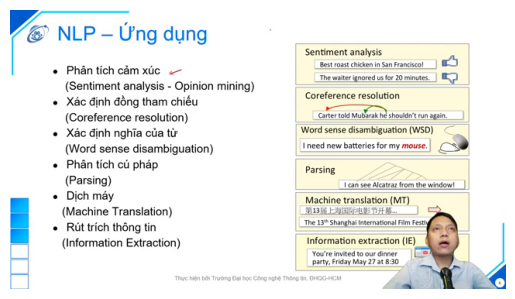

In [35]:
# # Thực thi (Ví dụ lấy frame ở giây thứ 500)
# if os.path.exists(VIDEO_PATH):
#     extrac_keyframe(VIDEO_PATH, 700, FRAME_PATH)

### Chạy 2 model OCR (Qwen2-VL & DeepSeek-VL)

In [36]:
# # --- MODEL 1: QWEN2-VL ---
# def run_qwen2_ocr(image_path):
#     print("\n--- Running Qwen2-VL-2B OCR ---")
#     model_id = "Qwen/Qwen2-VL-2B-Instruct"
#     model = Qwen2VLForConditionalGeneration.from_pretrained(model_id, torch_dtype="auto", device_map="auto")
#     processor = AutoProcessor.from_pretrained(model_id)

#     image = Image.open(image_path)
#     messages = [{"role": "user", "content": [{"type": "image", "image": image_path}, {"type": "text", "text": "Trích xuất toàn bộ văn bản trong ảnh."}]}]
#     text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
#     inputs = processor(text=[text], images=[image], padding=True, return_tensors="pt").to(device)

#     with torch.no_grad():
#         generated_ids = model.generate(**inputs, max_new_tokens=512)

#     generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
#     return processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)[0]

In [37]:
# if os.path.exists(FRAME_PATH):
#     print("KẾT QUẢ QWEN2:", run_qwen2_ocr(FRAME_PATH))


--- Running Qwen2-VL-2B OCR ---


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

KẾT QUẢ QWEN2: The image contains a slide from a presentation on Natural Language Processing (NLP). The slide is titled "NLP - Ứng dụng" (NLP - Applications). The content of the slide is as follows:

1. Phân tích cảm xúc (Sentiment analysis - Opinion mining)
2. Xác định dòng tham chiếu (Coreference resolution)
3. Xác định nghĩa của từ (Word sense disambiguation - WSD)
4. Phân tích câu phức (Parsing)
5. Dịch máy (Machine Translation)
6. Rút trích thông tin (Information Extraction - IE)

The slide also includes a list of examples of NLP applications, such as sentiment analysis, coreference resolution, word sense disambiguation, parsing, machine translation, and information extraction. The presenter is identified as Trương Duy Trường, from the Department of Computer Science, DHQG-HCM.


In [40]:
# def run_deepseek_ocr(image_path):
#     print("\n--- Running DeepSeek-VL-1.3B OCR ---")
#     model_path = "deepseek-ai/deepseek-vl-1.3b-chat"
#     vl_chat_processor = VLChatProcessor.from_pretrained(model_path)

#     # Sửa lỗi meta tensor bằng cách load trực tiếp vào device mà không dùng device_map="auto"
#     vl_gpt = MultiModalityCausalLM.from_pretrained(
#         model_path,
#         torch_dtype=torch.bfloat16
#     ).to(device)

#     image = Image.open(image_path).convert('RGB')
#     messages = [{"role": "User", "content": "<image_placeholder>Trích xuất văn bản từ hình ảnh này.", "images": [image_path]}, {"role": "Assistant", "content": ""}]

#     pil_images = load_pil_images(messages)
#     prepare_inputs = vl_chat_processor(conversations=messages, images=pil_images, force_batchify=True).to(device)
#     inputs_embeds = vl_gpt.prepare_inputs_embeds(**prepare_inputs)

#     with torch.no_grad():
#         outputs = vl_gpt.language_model.generate(
#             inputs_embeds=inputs_embeds,
#             attention_mask=prepare_inputs.attention_mask,
#             pad_token_id=vl_chat_processor.tokenizer.pad_token_id,
#             max_new_tokens=512
#         )
#     return vl_chat_processor.tokenizer.decode(outputs[0].cpu().tolist(), skip_special_tokens=True)

In [42]:
# import gc

# if os.path.exists(FRAME_PATH):

#     # Chạy OCR với DeepSeek
#     print("KẾT QUẢ DEEPSEEK:", run_deepseek_ocr(FRAME_PATH))


--- Running DeepSeek-VL-1.3B OCR ---


RuntimeError: Tensor.item() cannot be called on meta tensors